In [1]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

### Dataset

In [2]:
df = pd.read_csv('/kaggle/input/data-scraping-thesis-concated-data-cut/Data Scraping Thesis - Concated Data Cut.csv')

In [3]:
df['Final Label'].value_counts()

Final Label
Non-Negatif             8795
Provokasi               5302
Penghinaan              1135
Pornografi              1014
Negatif Lainnya          609
SARA                     511
Pencemaran Nama Baik     158
Name: count, dtype: int64

### Typo handling

In [4]:
abbr_dict = {
    "gk":"ga",
    "gx":"ga",
    "nggak":"ga",
    "gak":"ga",
    "kk":"kakak",
    "yg":"yang",
    "udh":"sudah",
    "udah":"sudah",
    "gw":"gue",
    "lo":"lu",
    "tp":"tapi",
    "lg":"lagi",
    "sm":"sama",
    "klo":"kalau",
    "klw":"kalau",
    "kalo":"kalau",
    "org":"orang",
    "w":"gue",
    "ku":"aku",
    "bru":"baru",
    "bgt":"banget",
    "si":"sih",
    "knp":"kenapa",
    "ato":"atau",
    "ky":"kaya",
    "bgst":"bangsat",
    "ajg":"anjing",
    "bg":"bang",
    "smg":"semoga"
}

In [5]:
def normalize_abbr(text, abbr_dict):
    pattern = r'\b(' + '|'.join(map(re.escape, abbr_dict.keys())) + r')\b'
    return re.sub(pattern, lambda x: abbr_dict[x.group()], text)

In [6]:
df.head()

,Comments,Final Label
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi


In [7]:
df['normalized_text'] = df['Comments'].apply(lambda x: normalize_abbr(x.lower(), abbr_dict))
df

,Comments,Final Label,normalized_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d..."
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga 20k kmrn ada yang post, tapi lupa di..."
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalau dah dewasa banget pengen ke msbree...
...,...,...,...
17519,haha kemarin ada yang prediksi bakal bagi-bagi...,Provokasi,haha kemarin ada yang prediksi bakal bagi-bagi...
17520,smg lebaran pakai baju oranye,Provokasi,semoga lebaran pakai baju oranye
17521,"yang Pro kak nikita, rata² orang² jujur yang s...",Non-Negatif,"yang pro kak nikita, rata² orang² jujur yang s..."
17522,mama gigi cantik bgt,Non-Negatif,mama gigi cantik banget


### Data Cleaning

In [8]:
def remove_punctuation_but_keep_emoticons(text):
    # Hapus karakter selain huruf, angka, spasi, dan rentang Unicode emotikon
    return re.sub(r'[^\w\s\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U0001F004-\U0001F0CF]', ' ', text)

def cleansing(df):
    df_clean = df.str.lower()  # Ubah semua teks menjadi huruf kecil
    df_clean = [re.sub(r"\d+", "", i) for i in df_clean]  # Hapus angka
    df_clean = [re.sub(r'http[s]?://\S+|www\.\S+', '', i) for i in df_clean]  # Hapus URL
    df_clean = [re.sub(r'@\S+', '', i) for i in df_clean]  # Hapus mention @username
    df_clean = [remove_punctuation_but_keep_emoticons(i) for i in df_clean]
    df_clean = [re.sub(r'\s+', ' ', i) for i in df_clean]  # Ganti spasi berlebih dengan satu spasi
    df_clean = [re.sub(r'(.)\1{2,}', r'\1\1', i) for i in df_clean]
    return df_clean

In [9]:
df['clean_text'] = cleansing(df['normalized_text'])

In [10]:
df.head()

,Comments,Final Label,normalized_text,clean_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d...",review nasi goreng ca dong dulu sih mangkal de...
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁,🤣🤣senggol bib gass kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga 20k kmrn ada yang post, tapi lupa di...",ada harga k kmrn ada yang post tapi lupa diman...
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalau dah dewasa banget pengen ke msbree...,nanti kalau dah dewasa banget pengen ke msbree...


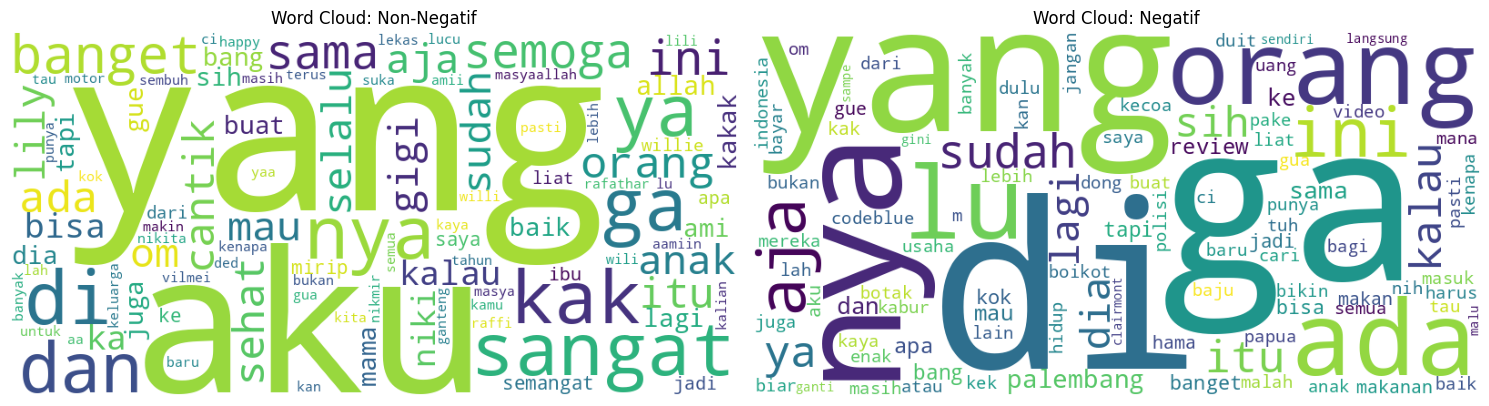

In [31]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast

# ===== 1️⃣ Pastikan clean_text bentuknya list =====
def ensure_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)  # kalau bentuknya "[ 'kata1', 'kata2' ]"
        except:
            return x.split()  # kalau cuma string biasa
    return x

df['clean_text'] = df['clean_text'].apply(ensure_list)

# ===== 2️⃣ Filter label =====
non_negatif_data = df[df['Final Label'] == 'Non-Negatif']
negatif_data = df[df['Final Label'] != 'Non-Negatif']

# ===== 3️⃣ Gabungkan jadi text utuh =====
non_negatif_text = " ".join(
    non_negatif_data['clean_text'].apply(lambda x: " ".join(x))
)

negatif_text = " ".join(
    negatif_data['clean_text'].apply(lambda x: " ".join(x))
)

# ===== 4️⃣ Generate WordCloud =====
wordcloud_non_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    collocations=False  # supaya nggak aneh-aneh gabung kata
).generate(non_negatif_text)

wordcloud_negatif = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    collocations=False
).generate(negatif_text)

# ===== 5️⃣ Plot =====
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(wordcloud_non_negatif)
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

axes[1].imshow(wordcloud_negatif)
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif")

plt.tight_layout()
plt.show()

### Lemma - Stanza

In [11]:
pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.0 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [12]:
import re
import torch
import stanza
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [13]:
import stanza

stanza.download('id')
nlp = stanza.Pipeline(lang='id', processors='tokenize,pos,lemma')

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [word.lemma for sent in doc.sentences for word in sent.words]
    return " ".join(lemmas)

2026-02-14 14:39:12 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-14 14:39:12 INFO: Downloading default packages for language: id (Indonesian) ...


2026-02-14 14:39:15 INFO: Downloaded file to /root/stanza_resources/id/default.zip
2026-02-14 14:39:18 INFO: Finished downloading models and saved to /root/stanza_resources
2026-02-14 14:39:18 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-02-14 14:39:18 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-14 14:39:18 WARNING: Language id package default expects mwt, which has been added
2026-02-14 14:39:18 INFO: Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |

2026-02-14 14:39:18 INFO: Using device: cuda
2026-02-14 14:39:18 INFO: Loading: tokenize
2026-02-14 14:39:19 INFO: Loading: mwt
2026-02-14 14:39:19 INFO: Loading: pos
2026-02-14 14:39:21 INFO: Loading: lemma
2026-02-14 14:39:21 INFO: Done loading processors!


In [14]:
df.head()

,Comments,Final Label,normalized_text,clean_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d...",review nasi goreng ca dong dulu sih mangkal de...
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁,🤣🤣senggol bib gass kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga 20k kmrn ada yang post, tapi lupa di...",ada harga k kmrn ada yang post tapi lupa diman...
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalau dah dewasa banget pengen ke msbree...,nanti kalau dah dewasa banget pengen ke msbree...


In [15]:
df['lemma_text'] = df['clean_text'].apply(lemmatize_text)

In [16]:
df

,Comments,Final Label,normalized_text,clean_text,lemma_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d...",review nasi goreng ca dong dulu sih mangkal de...,review nasi goreng ca dong dulu sih mangkal de...
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁,🤣🤣senggol bib gass kasih paham😁,🤣🤣senggol bib gass kasih paham 😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga 20k kmrn ada yang post, tapi lupa di...",ada harga k kmrn ada yang post tapi lupa diman...,ada harga k kmrn ada yang post tetapi lupa dim...
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalau dah dewasa banget pengen ke msbree...,nanti kalau dah dewasa banget pengen ke msbree...,nanti kalau dah dewasa banget pengen ke msbree...
...,...,...,...,...,...
17519,haha kemarin ada yang prediksi bakal bagi-bagi...,Provokasi,haha kemarin ada yang prediksi bakal bagi-bagi...,haha kemarin ada yang prediksi bakal bagi bagi...,haha kemarin ada yang prediksi bakal bagi bagi...
17520,smg lebaran pakai baju oranye,Provokasi,semoga lebaran pakai baju oranye,semoga lebaran pakai baju oranye,semoga lebar pakai baju oranye
17521,"yang Pro kak nikita, rata² orang² jujur yang s...",Non-Negatif,"yang pro kak nikita, rata² orang² jujur yang s...",yang pro kak nikita rata² orang² jujur yang se...,yang pro kak nikita rata² orang² jujur yang se...
17522,mama gigi cantik bgt,Non-Negatif,mama gigi cantik banget,mama gigi cantik banget,mama gigi cantik banget


In [17]:
label_map = {
    "Provokasi": 0,
    "Penghinaan": 1,
    "Pornografi": 2,
    "Negatif Lainnya": 3,
    "SARA": 4,
    "Pencemaran Nama Baik": 5,
    "Non-Negatif": 6
}

In [18]:
df['label_encoded'] = df['Final Label'].map(label_map)

### Split Data

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
from sklearn.model_selection import train_test_split

# 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    df['lemma_text'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [21]:
print("Jumlah data:")
print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

Jumlah data:
Train      : 14019
Validation : 1752
Test       : 1753


### Load IndoBERT pakai Automodel

In [22]:
import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p2")

model.eval()

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

2026-02-14 14:58:04.045994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771081084.269590      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771081084.334334      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771081084.887670      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771081084.887709      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771081084.887711      55 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### Extract CLS Embedding

In [23]:
def get_embedding(text):
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding.squeeze().numpy()

### Ubah semua Text jadi Embedding

In [24]:
X_train_emb = np.array([get_embedding(text) for text in X_train])
X_val_emb   = np.array([get_embedding(text) for text in X_val])
X_test_emb  = np.array([get_embedding(text) for text in X_test])

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

### Train Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_emb, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

### Data Validation

In [38]:
from sklearn.metrics import classification_report

y_val_pred = rf.predict(X_val_emb)
print("Validation Result")
print(classification_report(y_val, y_val_pred))

Validation Result
              precision    recall  f1-score   support

           0       0.63      0.66      0.65       530
           1       0.78      0.19      0.30       113
           2       0.62      0.05      0.09       102
           3       0.40      0.07      0.11        61
           4       0.83      0.29      0.43        51
           5       0.00      0.00      0.00        16
           6       0.69      0.89      0.77       879

    accuracy                           0.67      1752
   macro avg       0.56      0.31      0.34      1752
weighted avg       0.66      0.67      0.63      1752



### Data Test

In [39]:
y_test_pred = rf.predict(X_test_emb)
print("Test Result")
print(classification_report(y_test, y_test_pred))

Test Result
              precision    recall  f1-score   support

           0       0.65      0.64      0.65       530
           1       0.83      0.22      0.35       114
           2       1.00      0.02      0.04       101
           3       0.40      0.10      0.16        61
           4       0.75      0.18      0.29        51
           5       0.00      0.00      0.00        16
           6       0.67      0.90      0.77       880

    accuracy                           0.67      1753
   macro avg       0.62      0.29      0.32      1753
weighted avg       0.68      0.67      0.62      1753



### Latency

In [40]:
import time

print("- Concated Data Cut")
print(f"- Train: {len(X_train)}, "
      f"Val: {len(X_val)}, "
      f"Test: {len(X_test)}")

start = time.time()
y_pred = rf.predict(X_test_emb)
end = time.time()

total_time = end - start
total_data = len(X_test)

print(f"- {total_time:.2f}s for {total_data} data")
print(f"- Avg latency: {total_time/total_data:.5f} s/sample")
print(f"- Throughput: {total_data/total_time:.2f} samples/second")

- Concated Data Cut
- Train: 14019, Val: 1752, Test: 1753
- 0.28s for 1753 data
- Avg latency: 0.00016 s/sample
- Throughput: 6289.09 samples/second


In [41]:
import pandas as pd

# Predict
y_pred = rf.predict(X_test_emb)

# Buat tabel hasil
hasil_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Tampilkan 10 pertama
hasil_df.head(10)

,Text,Actual,Predicted
0,likes gini banyak nya dr mana sih lu bang 😢 mi...,0,6
1,,6,6
2,oalah gini ya cara maenya👏,0,6
3,masyaal lah cantik nya teh lily ❤ mama gii,6,6
4,dia siapa sampe se pantes itu review dia,0,0
5,boicot spesies ini,0,6
6,akhir dia liat juga cetak canele ya,6,0
7,wkakakakakak,6,6
8,tombol kak nada cantik bnget 👉,6,6
9,skin legend you mie skin 🗿,6,6
